# MSCS 634 - Lab 1: Data Analysis & Preprocessing
**Student Name:** Abhinay Darana  
**Course Title:** MSCS 634 
**Assignment:** Lab 1 Submission

In [12]:
# Imports and Dataset Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Sets aesthetic style for charts
sns.set_theme(style="whitegrid")

# Sample dataset
data = {
    'Transaction_ID': range(101, 126),
    'Age': [22, 25, 47, 52, 46, np.nan, 23, 38, 59, 32, 28, 41, np.nan, 35, 50, 21, 64, 31, 29, 45, 33, 39, 27, 85, 24],
    'Annual_Income': [45000, 54000, 85000, 92000, 78000, 61000, 48000, 71000, 105000, 63000, 58000, 82000, 67000, 75000, 98000, 42000, 120000, 62000, 59000, 88000, 66000, 79000, 52000, 250000, 49000],
    'Spending_Score': [39, 81, 6, 77, 40, 76, 94, 72, 14, 14, 82, 12, 18, 55, 35, 87, 16, 51, 79, 41, 53, 48, 73, 5, 80],
    'Department': ['Clothing', 'Sports', 'Home', 'Home', 'Clothing', 'Sports', 'Clothing', 'Home', 'Sports', 'Clothing', 'Sports', 'Home', 'Clothing', 'Sports', 'Home', 'Clothing', 'Home', 'Sports', 'Clothing', 'Home', 'Sports', 'Home', 'Clothing', 'Home', 'Sports']
}

df = pd.DataFrame(data)

# first 5 rows
df.head()

,Transaction_ID,Age,Annual_Income,Spending_Score,Department
0,101,22.0,45000,39,Clothing
1,102,25.0,54000,81,Sports
2,103,47.0,85000,6,Home
3,104,52.0,92000,77,Home
4,105,46.0,78000,40,Clothing


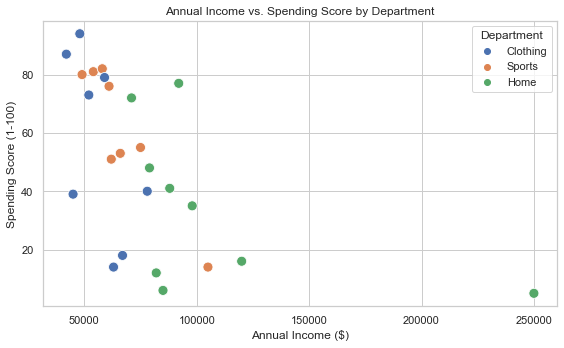

In [3]:
# Visualization 1 - Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Department', s=100)
plt.title('Annual Income vs. Spending Score by Department')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()


# Insight 1: High-income individuals in the Home department tend to have lower spending scores, 
# whereas younger or mid-income customers in Sports and Clothing show higher spending scores.

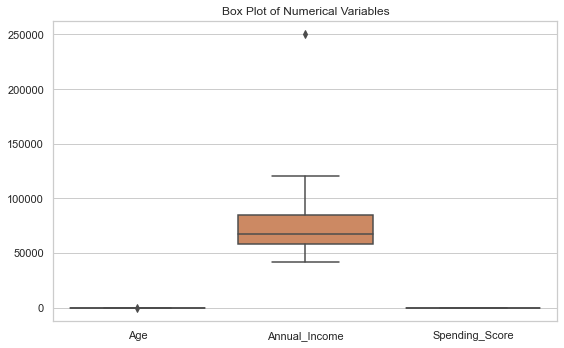

In [4]:
# Visualization 2 - Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['Age', 'Annual_Income', 'Spending_Score']])
plt.title('Box Plot of Numerical Variables')
plt.tight_layout()
plt.show()


# Insight 2: Highlights scale differences among features and visually identifies 
# an upper outlier in Annual_Income ($250,000) relative to the rest of the sample.

In [5]:
# Cell 4: Detect and Impute Missing Values
print("Missing values before handling:")
print(df.isnull().sum())

df_clean = df.copy()
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())


print("\nMissing values after median imputation:")
print(df_clean.isnull().sum())

Missing values before handling:
Transaction_ID    0
Age               2
Annual_Income     0
Spending_Score    0
Department        0
dtype: int64

Missing values after median imputation:
Transaction_ID    0
Age               0
Annual_Income     0
Spending_Score    0
Department        0
dtype: int64


In [6]:
# Cell 5: Outlier Detection using Interquartile Range (IQR)
Q1 = df_clean['Annual_Income'].quantile(0.25)
Q3 = df_clean['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

outliers = df_clean[(df_clean['Annual_Income'] < lower_bound) | (df_clean['Annual_Income'] > upper_bound)]
print("\nIdentified Outliers:")
print(outliers[['Transaction_ID', 'Annual_Income']])

df_no_outliers = df_clean[(df_clean['Annual_Income'] >= lower_bound) & (df_clean['Annual_Income'] <= upper_bound)]


print(f"\nShape before outlier removal: {df_clean.shape}")
print(f"Shape after outlier removal: {df_no_outliers.shape}")

Q1: 58000.0, Q3: 85000.0, IQR: 27000.0
Lower Bound: 17500.0, Upper Bound: 125500.0

Identified Outliers:
    Transaction_ID  Annual_Income
23             124         250000

Shape before outlier removal: (25, 5)
Shape after outlier removal: (24, 5)


In [7]:
# Cell 6: Sampling and Column Elimination
df_reduced = df_no_outliers.drop(columns=['Transaction_ID'])
df_sampled = df_reduced.sample(frac=0.8, random_state=42)


print(f"Original shape: {df.shape}")
print(f"Reduced & Sampled shape: {df_sampled.shape}")
df_sampled.head()

Original shape: (25, 5)
Reduced & Sampled shape: (19, 4)


,Age,Annual_Income,Spending_Score,Department
8,59.0,105000,14,Sports
16,64.0,120000,16,Home
0,22.0,45000,39,Clothing
18,29.0,59000,79,Clothing
11,41.0,82000,12,Home


In [8]:
# Cell 7: Min-Max Scaling & Discretization
df_scaled = df_sampled.copy()

scaler = MinMaxScaler()
df_scaled['Income_Scaled'] = scaler.fit_transform(df_scaled[['Annual_Income']])

df_scaled['Age_Group'] = pd.cut(
    df_scaled['Age'], 
    bins=[0, 30, 50, 100], 
    labels=['Young Adult', 'Middle Aged', 'Senior']
)


df_scaled[['Age', 'Age_Group', 'Annual_Income', 'Income_Scaled']].head()

,Age,Age_Group,Annual_Income,Income_Scaled
8,59.0,Senior,105000,0.807692
16,64.0,Senior,120000,1.000000
0,22.0,Young Adult,45000,0.038462
18,29.0,Young Adult,59000,0.217949
11,41.0,Middle Aged,82000,0.512821


In [9]:
# Cell 8: General Overview
print("--- DATASET INFO ---")
df_clean.info()

print("\n--- DESCRIPTIVE STATISTICS ---")

df_clean.describe()

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  25 non-null     int64  
 1   Age             25 non-null     float64
 2   Annual_Income   25 non-null     int64  
 3   Spending_Score  25 non-null     int64  
 4   Department      25 non-null     object 
dtypes: float64(1), int64(3), object(1)
memory usage: 1.1+ KB

--- DESCRIPTIVE STATISTICS ---


,Transaction_ID,Age,Annual_Income,Spending_Score
count,25.000000,25.000000,25.000000,25.000000
mean,113.000000,38.640000,77960.000000,49.920000
std,7.359801,15.046816,40861.024624,29.005632
min,101.000000,21.000000,42000.000000,5.000000
25%,107.000000,28.000000,58000.000000,18.000000
50%,113.000000,35.000000,67000.000000,51.000000
75%,119.000000,46.000000,85000.000000,77.000000
max,125.000000,85.000000,250000.000000,94.000000


In [10]:
# Cell 9: Central Tendency & Dispersion Measures
num_cols = ['Age', 'Annual_Income', 'Spending_Score']

stats_df = pd.DataFrame({
    'Min': df_clean[num_cols].min(),
    'Max': df_clean[num_cols].max(),
    'Mean': df_clean[num_cols].mean(),
    'Median': df_clean[num_cols].median(),
    'Mode': df_clean[num_cols].mode().iloc[0],
    'Range': df_clean[num_cols].max() - df_clean[num_cols].min(),
    'IQR': df_clean[num_cols].quantile(0.75) - df_clean[num_cols].quantile(0.25),
    'Variance': df_clean[num_cols].var(),
    'Std Dev': df_clean[num_cols].std()
})


stats_df

,Min,Max,Mean,Median,Mode,Range,IQR,Variance,Std Dev
Age,21.0,85.0,38.64,35.0,35.0,64.0,18.0,2.264067e+02,15.046816
Annual_Income,42000.0,250000.0,77960.00,67000.0,42000.0,208000.0,27000.0,1.669623e+09,40861.024624
Spending_Score,5.0,94.0,49.92,51.0,14.0,89.0,59.0,8.413267e+02,29.005632


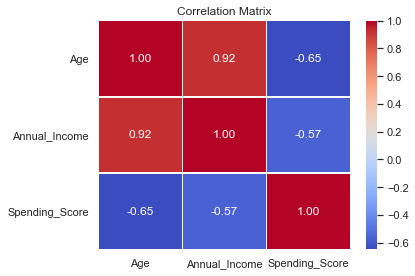

,Age,Annual_Income,Spending_Score
Age,1.000000,0.924760,-0.647634
Annual_Income,0.924760,1.000000,-0.565203
Spending_Score,-0.647634,-0.565203,1.000000


In [11]:
# Cell 10: Correlation Analysis
corr_matrix = df_clean[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

corr_matrix